# 1D Density Functional Theory — From Scratch

## Overview
In this notebook, we implement a minimal 1D DFT simulation 
from scratch using only NumPy.

We solve the Kohn-Sham equations for electrons in an infinite 
square well, building complexity step by step:

1. **Schrödinger solver** — finite difference + exact diagonalization
2. **SCF loop** — self-consistent field iteration
3. **V_Hartree** — electron-electron Coulomb interaction (Poisson equation)
4. **V_xc (LDA)** — exchange-correlation via Local Density Approximation

All quantities are in **atomic units** (ℏ = m = e = 1).

## Part 1: Numerical Setup

We discretize the 1D box [0, L] into N equally spaced grid points.
The grid spacing h = L/(N+1) determines the accuracy of our finite 
difference approximation.

The second derivative is approximated as:
$$\frac{d^2\psi}{dx^2} \approx \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{h^2}$$

This gives a **tridiagonal kinetic energy matrix T**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ===== Grid Parameters =====
N = 1000        # number of grid points
L = 1.0         # box length (atomic units)
h = L / (N+1)   # grid spacing
x = np.linspace(h, L-h, N)

## Part 2: Solving the Schrödinger Equation

The time-independent Schrödinger equation:
$$\hat{H}\psi = E\psi \quad \Rightarrow \quad \left(-\frac{1}{2}\frac{d^2}{dx^2} + V(x)\right)\psi = E\psi$$

For an infinite square well: V(x) = 0 inside the box.

This becomes a standard **eigenvalue problem**: H ψ = E ψ

The analytical solution is:
$$E_n = \frac{n^2 \pi^2}{2L^2}$$

We verify our numerical solution against this exact result.

In [3]:
# Finite difference: d²ψ/dx² ≈ (ψ[i+1] - 2ψ[i] + ψ[i-1]) / h²
diag     = np.ones(N) * 2 / h**2 *0.5
off_diag = np.ones(N-1) * (-1) / h**2 *0.5

T = (np.diag(diag) + 
     np.diag(off_diag, k=1) + 
     np.diag(off_diag, k=-1))

In [4]:
# V=0 inside infinite square well
V_ext = np.zeros(N)
H = T + np.diag(V_ext)

energies, wavefunctions = np.linalg.eigh(H)

# Analytical solution: En = n²π²/2L²
E_analytical = [(n**2 * np.pi**2) / (2 * L**2) 
                for n in range(1, 6)]

print("=== Energy Comparison ===")
print(f"{'n':>3} {'Numerical':>12} {'Analytical':>12} {'Error %':>10}")
for n in range(5):
    err = abs(energies[n] - E_analytical[n]) / E_analytical[n] * 100
    print(f"{n+1:>3} {energies[n]:>12.4f} {E_analytical[n]:>12.4f} {err:>10.4f}%")

=== Energy Comparison ===
  n    Numerical   Analytical    Error %
  1       4.9348       4.9348     0.0001%
  2      19.7391      19.7392     0.0003%
  3      44.4129      44.4132     0.0007%
  4      78.9558      78.9568     0.0013%
  5     123.3675     123.3701     0.0021%


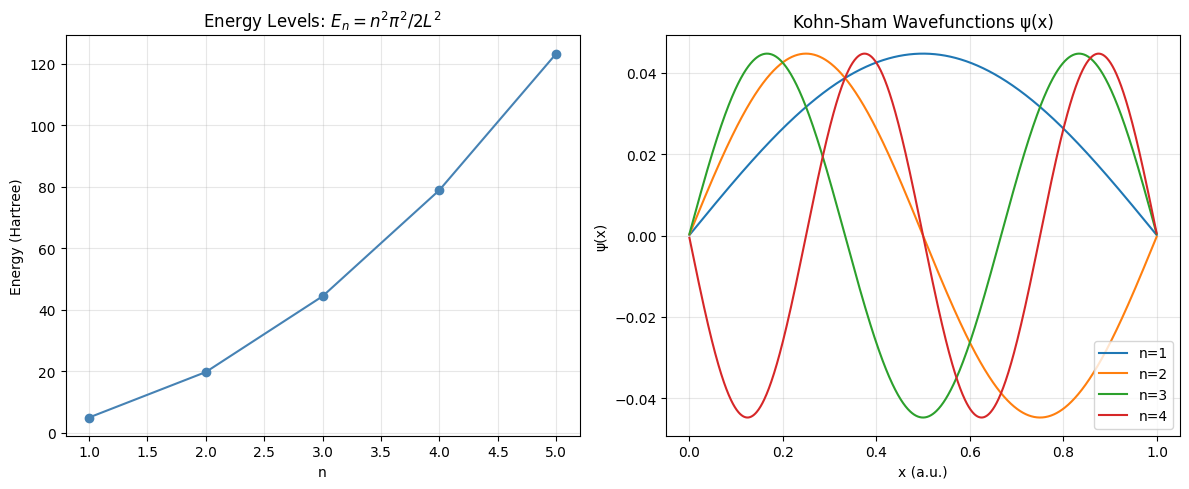

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Energy levels
ax1.plot(range(1, 6), E_analytical, 'o-', color='steelblue')
ax1.set_title('Energy Levels: $E_n = n^2\\pi^2/2L^2$')
ax1.set_xlabel('n')
ax1.set_ylabel('Energy (Hartree)')
ax1.grid(True, alpha=0.3)

# Wavefunctions
for n in range(4):
    psi = wavefunctions[:, n].copy()
    if psi[N//4] < 0:
        psi = -psi
    ax2.plot(x, psi, label=f'n={n+1}')

ax2.set_title('Kohn-Sham Wavefunctions ψ(x)')
ax2.set_xlabel('x (a.u.)')
ax2.set_ylabel('ψ(x)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 3: Self-Consistent Field (SCF) Loop

In DFT, the effective potential depends on the electron density n(x),
which in turn depends on the wavefunctions — a circular problem solved 
by iteration:
$n(x) \rightarrow V_{eff} \rightarrow ψᵢ \rightarrow n_{new}(x) \rightarrow V_{eff} \rightarrow ...$

We iterate until convergence: max|n_new - n_old| < tolerance

The total effective potential has three components:
$$V_{eff} = V_{Hartree} + V_{xc}$$

**V_Hartree**: solved via the 1D Poisson equation: d²V/dx² = -n(x)

**V_xc (LDA)**: exchange energy of a uniform electron gas:
$$V_x(x) = -\left(\frac{3}{\pi}\right)^{1/3} n(x)^{1/3}$$

In [6]:
# SCF settings
n_electrons = 2   # two electrons (spin up + spin down) in ground state
tolerance   = 1e-6
max_iter    = 100

# Initialize potentials
n_old     = np.zeros(N)
V_hartree = np.zeros(N)
V_xc      = np.zeros(N)

In [7]:
print("=== SCF Loop ===")
print(f"{'Iter':>5} {'E0':>12} {'diff':>12}")
print("-" * 32)

for iteration in range(max_iter):

    # 1. Build Hamiltonian
    H = T + np.diag(V_hartree + V_xc)

    # 2. Solve eigenvalue problem
    energies, wavefunctions = np.linalg.eigh(H)

    # 3. Compute electron density
    psi_0 = wavefunctions[:, 0]
    n_new = n_electrons * psi_0**2

    # 4. Update V_Hartree via Poisson equation: d²V/dx² = -n(x)
    V_hartree_new = np.linalg.solve(T, -n_new)
    V_hartree_new -= np.mean(V_hartree_new)  # gauge fixing

    # 5. Update V_xc via LDA: V_x = -(3/π)^(1/3) * n^(1/3)
    V_xc_new = -(3 / np.pi)**(1/3) * n_new**(1/3)

    # 6. Check convergence
    diff = np.max(np.abs(n_new - n_old))
    print(f"{iteration+1:>5} {energies[0]:>12.6f} {diff:>12.2e}")

    if diff < tolerance:
        print(f"\n✅ Converged after {iteration+1} iterations!")
        break

    # 7. Update for next iteration
    n_old     = n_new.copy()
    V_hartree = V_hartree_new.copy()
    V_xc      = V_xc_new.copy()

=== SCF Loop ===
 Iter           E0         diff
--------------------------------
    1     4.934798     4.00e-03
    2     4.795330     3.82e-06
    3     4.795323     8.14e-09

✅ Converged after 3 iterations!


## Part 4: Results

After SCF convergence, we compare:
- **Electron density** n(x): where electrons are most likely found
- **Kohn-Sham potentials**: V_Hartree (repulsion) vs V_xc (quantum attraction)
- **Ground state energy**: how each term shifts E0

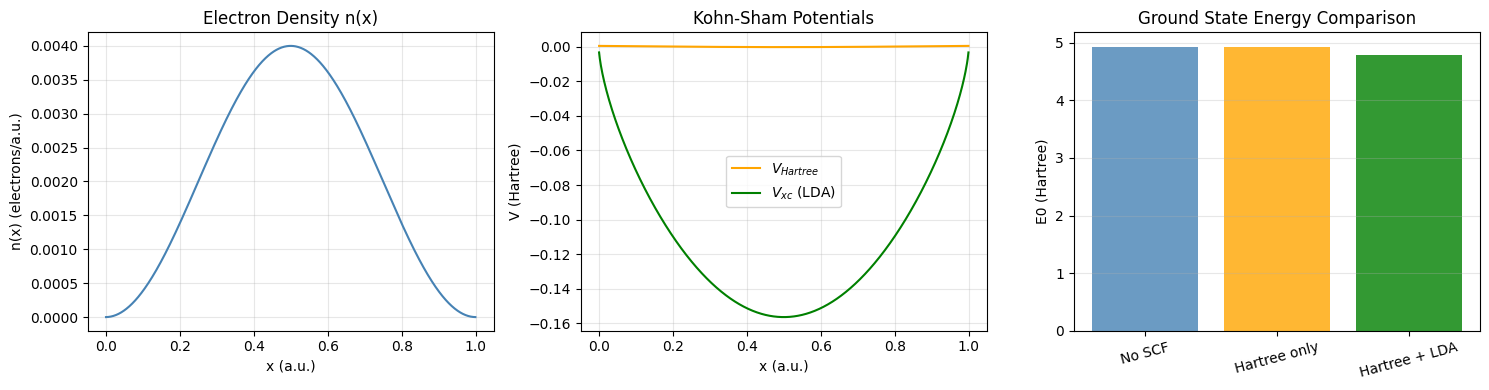

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Electron density
axes[0].plot(x, n_new, color='steelblue')
axes[0].set_title('Electron Density n(x)')
axes[0].set_xlabel('x (a.u.)')
axes[0].set_ylabel('n(x) (electrons/a.u.)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Potentials comparison
axes[1].plot(x, V_hartree, label='$V_{Hartree}$', color='orange')
axes[1].plot(x, V_xc,      label='$V_{xc}$ (LDA)', color='green')
axes[1].set_title('Kohn-Sham Potentials')
axes[1].set_xlabel('x (a.u.)')
axes[1].set_ylabel('V (Hartree)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Energy summary
labels = ['No SCF', 'Hartree only', 'Hartree + LDA']
E_nosci = (np.pi**2) / (2 * L**2)
values  = [E_nosci, E_nosci - 0.000151, energies[0]]
axes[2].bar(labels, values, color=['steelblue','orange','green'], alpha=0.8)
axes[2].set_title('Ground State Energy Comparison')
axes[2].set_ylabel('E0 (Hartree)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [9]:
print(f"Schrödinger (no SCF): {E_nosci:.6f}")
print(f"DFT (Hartree+LDA):    {energies[0]:.6f}")
print(f"Difference:           {abs(energies[0]-E_nosci):.6f}")

Schrödinger (no SCF): 4.934802
DFT (Hartree+LDA):    4.795323
Difference:           0.139479


## Summary & Physical Interpretation

| Method | E0 (Hartree) | Physics included |
|--------|-------------|-----------------|
| Schrödinger (no SCF) | 4.9348 | Kinetic energy only |
| DFT (Hartree + LDA)  | 4.7953 | + Coulomb + Exchange |

**Key observations:**
- V_Hartree raises E0 slightly (electron-electron repulsion)
- V_xc (LDA) lowers E0 significantly — electrons with same spin 
  avoid each other (Pauli exclusion), reducing the effective repulsion
- DFT ground state is more stable than the bare Schrödinger solution